## Notebook Overview

## Regression Analysis

- This notebook implements a complete preprocessing and modeling pipeline for predicting ISUP grades from radiomic features. It evaluates several regression models on a balanced feature set.

Data Loading and Merging
- Radiomic features and clinical labels are merged using `study_id`, producing a unified dataset containing predictors and ISUP grades.

Class‑0 Undersampling via Nearest Neighbors
- To reduce the dominance of ISUP class 0, each minority‑class sample (1–5) is paired with its nearest class‑0 neighbor.  
Only these selected class‑0 samples are retained, producing a more balanced dataset before oversampling.

SMOTE 
- SMOTE is applied **only** to classes 3, 4, and 5, increasing each to 150 samples while leaving classes 0–2 unchanged.  

Regression Modeling
Three regression approaches are evaluated:
- Standard Linear Regression  
- Linear Regression with ANOVA feature selection  
- Lasso Regression with cross‑validated regularization  

All models use standardized predictors and targets.

Evaluation and Feature Analysis"
- Model performance is assessed using MSE and R².  
- Spearman correlations are computed to identify radiomic features most associated with ISUP grade.


In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE 
from deep_gp.preprocessing_data import load_data, undersample_class0, apply_smote

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
data = load_data()
df_new = undersample_class0(data)
df_resampled = apply_smote(df_new)

X_balanced = df_resampled.drop(columns=["case_ISUP"])
y_balanced = df_resampled["case_ISUP"]


In [14]:
# Check for the shapes
print("For undersampling class 0:",df_new.shape)
print("After applying SMOTE:",df_resampled.shape)
print("Number of patients and predictors:",X_balanced.shape)

For undersampling class 0: (704, 108)
After applying SMOTE: (1023, 108)
Number of patients and predictors: (1023, 107)


In [15]:
print("\n Original class counts ")
print(data["case_ISUP"].value_counts().sort_index())
print("\nFinal class counts AFTER Undersampling class 0 and SMOTE:")
print(df_resampled["case_ISUP"].value_counts().sort_index())



 Original class counts 
case_ISUP
0    589
1    157
2    154
3     69
4     27
5     35
Name: count, dtype: int64

Final class counts AFTER Undersampling class 0 and SMOTE:
case_ISUP
0    262
1    157
2    154
3    150
4    150
5    150
Name: count, dtype: int64


In [16]:
# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)


In [17]:
# Scale predictors 
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

# Scale target 
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()


In [18]:
# Fit Linear Regression
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MSE: 3.002776822132055
R²: 0.08932888828678931


In [19]:
## Linear Regression with ANOVA-selected features

selector = SelectKBest(score_func=f_regression, k=10)
X_selected = selector.fit_transform(X_balanced, y_balanced)
selected_features = X_balanced.columns[selector.get_support()]
print("Selected features (ANOVA):", selected_features.tolist())

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_balanced[selected_features], y_balanced, test_size=0.2, random_state=42
)

scaler_X_sel = StandardScaler()
X_train_sel_scaled = scaler_X_sel.fit_transform(X_train_sel)
X_test_sel_scaled  = scaler_X_sel.transform(X_test_sel)

scaler_y_sel = StandardScaler()
y_train_sel_scaled = scaler_y_sel.fit_transform(y_train_sel.values.reshape(-1,1)).ravel()
y_test_sel_scaled  = scaler_y_sel.transform(y_test_sel.values.reshape(-1,1)).ravel()

# Fit Linear Regression
lr = LinearRegression()
lr.fit(X_train_sel_scaled, y_train_sel_scaled)
y_pred_sel_scaled = lr.predict(X_test_sel_scaled)
y_pred_sel = scaler_y_sel.inverse_transform(y_pred_sel_scaled.reshape(-1,1)).ravel()

print("\n--- Linear Regression (ANOVA-selected features, balanced) ---")
print("MSE:", mean_squared_error(y_test_sel, y_pred_sel))
print("R²:", r2_score(y_test_sel, y_pred_sel))


Selected features (ANOVA): ['original_shape_LeastAxisLength', 'original_shape_MajorAxisLength', 'original_shape_MeshVolume', 'original_shape_MinorAxisLength', 'original_shape_Sphericity', 'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio', 'original_shape_VoxelVolume', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_glszm_GrayLevelNonUniformity']

--- Linear Regression (ANOVA-selected features, balanced) ---
MSE: 3.037820493536421
R²: 0.07870097249860664


In [20]:
## Lasso Regression 

X_train_lasso, X_test_lasso, y_train_lasso, y_test_lasso = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

scaler_lasso = StandardScaler()
X_train_lasso_scaled = scaler_lasso.fit_transform(X_train_lasso)
X_test_lasso_scaled  = scaler_lasso.transform(X_test_lasso)

# Fit Lasso
lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=50000,
    tol=1e-4,
    alphas=np.logspace(-3, 1, 50)
).fit(X_train_lasso_scaled, y_train_lasso)

y_pred_lasso = lasso.predict(X_test_lasso_scaled)

print("\n--- Lasso Regression ---")
print("MSE:", mean_squared_error(y_test_lasso, y_pred_lasso))
print("R²:", r2_score(y_test_lasso, y_pred_lasso))
print("Number of selected features:", np.sum(lasso.coef_ != 0))

selected_by_lasso = X_balanced.columns[lasso.coef_ != 0]
print("Selected features:", selected_by_lasso.tolist())



--- Lasso Regression ---
MSE: 2.7558084198686013
R²: 0.1642285570832217
Number of selected features: 29
Selected features: ['original_shape_Elongation', 'original_shape_Flatness', 'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn', 'original_shape_Maximum2DDiameterRow', 'original_shape_Sphericity', 'original_firstorder_10Percentile', 'original_firstorder_InterquartileRange', 'original_firstorder_Kurtosis', 'original_firstorder_Minimum', 'original_firstorder_Skewness', 'original_firstorder_TotalEnergy', 'original_glcm_ClusterShade', 'original_glcm_Imc1', 'original_glcm_Imc2', 'original_glcm_MCC', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_gldm_SmallDependenceLowGrayLevelEmphasis', 'original_glrlm_RunLengthNonUniformityNormalized', 'original_glrlm_ShortRunEmphasis', 'original_glszm_GrayLevelNonUniformity', 'original_glszm_GrayLevelVariance', 'original_glszm_LargeAreaLowGrayLevelEmphasis', 'original_glszm_SmallAreaEmphasis', 'original_ngtdm_Bu

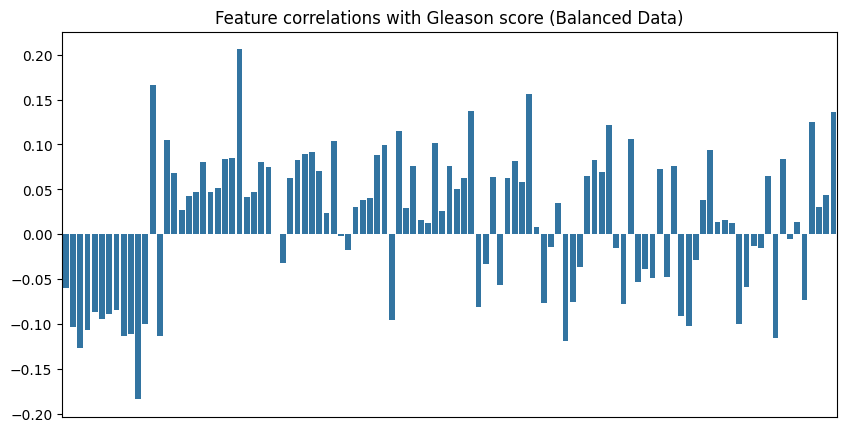

In [21]:
# Spearman correlation
corrs = X_balanced.corrwith(y_balanced, method='spearman')

plt.figure(figsize=(10,5))
sns.barplot(x=corrs.index, y=corrs.values)
plt.xticks([])
plt.xlabel("")
plt.title("Feature correlations with Gleason score (Balanced Data)")
plt.show()
